In [ ]:
!pip install kmodes

In [ ]:
# Import necessary libraries
import pandas as pd
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Create a Sample dataset with categorical features
data = {
    'Color': ['Red', 'Red', 'Blue', 'Blue', 'Green', 'Green', 'Red', 'Blue'],
    'Size': ['S', 'M', 'L', 'L', 'S', 'M', 'L', 'M'],
    'Shape': ['Circle', 'Square', 'Triangle', 'Circle', 'Square', 'Circle', 'Triangle', 'Square']
}

df = pd.DataFrame(data)

In [ ]:
# Convert categorical values to numeric codes (required by K-Modes)
df_encoded = df.apply(lambda x: x.astype('category').cat.codes)

In [ ]:
# Apply K-Modes clustering
km = KModes(n_clusters=3, init='huang', n_init=5, verbose=1, random_state=42)
clusters = km.fit_predict(df_encoded)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 8.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 8.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 1, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 9.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 6.0
Best run was number 5


In [ ]:
# Add cluster assignments to original DataFrame
df['Cluster'] = clusters

In [ ]:
# Print the cluster centroids
print("Cluster Centroids:")
print(km.cluster_centroids_)

Cluster Centroids:
[[0 0 2]
 [1 2 0]
 [0 1 1]]


In [ ]:
# Display clusterd data
print("Clustered Data:")
print(df)

Clustered Data:
   Color Size     Shape  Cluster
0    Red    S    Circle        1
1    Red    M    Square        2
2   Blue    L  Triangle        0
3   Blue    L    Circle        0
4  Green    S    Square        1
5  Green    M    Circle        1
6    Red    L  Triangle        0
7   Blue    M    Square        2


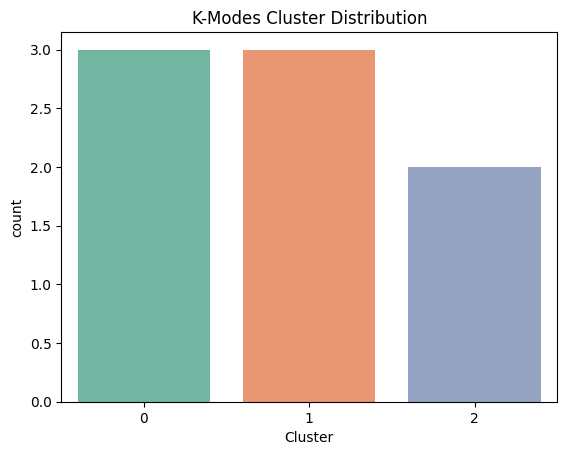

In [ ]:
# Optional: Visualize cluster distribution using a count plot
sns.countplot(x='Cluster', hue='Cluster', data=df, palette='Set2', legend=False)
plt.title("K-Modes Cluster Distribution")
plt.show()